# IrriGator — Block 0: Data Ingestion (Interactive)

Notebook equivalent of all CLI commands. Run cells in order.
Each section corresponds to one CLI command.

## 0. Setup

In [2]:
import logging
from datetime import date
from pathlib import Path
import os



# Show info-level logs in the notebook
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(name)s] %(levelname)s: %(message)s",
    datefmt="%H:%M:%S",
)
PARENT = str(os.path.dirname(os.getcwd()))



## 1. Generate a region config

**CLI equivalent:**
```bash
irrigator init-region --dept 24
```

Requires ADMIN EXPRESS shapefile from IGN. Skip this cell if you already have `configs/dordogne.yaml`.

In [2]:
from irrigator.region_builder import build_region_config


# Change these for your département
DEPT_CODE = "24"
OUTPUT_PATH = PARENT + "/configs/dordogne.yaml"
ADMIN_SHP = PARENT + "/data/static/admin_express/DEPARTEMENT.shp"  # adjust if needed

config = build_region_config(
    dept_code=DEPT_CODE,
    output_path=OUTPUT_PATH,
    admin_shp=ADMIN_SHP,
    parent_path=PARENT,
)

print(f"Region: {config['region']['name']}")
print(f"WGS84 bbox: {config['region']['bbox_wgs84']}")
print(f"L93 bbox:   {config['region']['bbox_l93']}")
print(f"Written to: {OUTPUT_PATH}")

12:06:51 [numexpr.utils] INFO: Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
12:06:51 [numexpr.utils] INFO: NumExpr defaulting to 16 threads.
12:06:51 [irrigator.region_builder] INFO: Loading admin boundaries from /home/mbaldacchino/code/IrriGator/data/static/admin_express/DEPARTEMENT.shp
12:06:52 [irrigator.region_builder] INFO: Config written: /home/mbaldacchino/code/IrriGator/configs/dordogne.yaml


Region: Dordogne
WGS84 bbox: {'north': 45.7148, 'south': 44.5707, 'west': -0.0419, 'east': 1.4482}
L93 bbox:   {'xmin': 460274, 'ymin': 6387574, 'xmax': 577773, 'ymax': 6515567}
Written to: /home/mbaldacchino/code/IrriGator/configs/dordogne.yaml


## 2. Load region config & build target grid

This is the starting point for everything else.

In [3]:
from irrigator.config import load_region_config
from irrigator.ingestion.grid import build_grid

cfg = load_region_config(PARENT + "/configs/dordogne.yaml")
grid = build_grid(cfg)

print(f"Region:     {cfg.name} (dept {cfg.code_departement})")
print(f"CRS:        {cfg.crs}")
print(f"Grid shape: {grid.shape[0]} rows × {grid.shape[1]} cols")
print(f"Grid cells: {grid.n_cells:,}")
print(f"Resolution: {grid.resolution_m} m")
print(f"Raw dir:    {cfg.raw_dir}")
print(f"Static dir: {cfg.static_dir}")

15:18:33 [irrigator.ingestion.grid] INFO: Grid built: 471 x 513 (241623 cells) at 250 m in EPSG:2154


Region:     Dordogne (dept 24)
CRS:        EPSG:2154
Grid shape: 513 rows × 471 cols
Grid cells: 241,623
Resolution: 250 m
Raw dir:    /home/mbaldacchino/code/IrriGator/data/raw/dordogne
Static dir: /home/mbaldacchino/code/IrriGator/data/static


## 3. Fetch ERA5-Land

**CLI equivalent:**
```bash
irrigator fetch era5 --start 2020-04-01 --end 2023-10-31
```

Downloads month by month. Takes a while — CDS queues can be slow.
Start with one month to test, then expand.

In [4]:
from irrigator.ingestion.cds_client import fetch_era5_land_month, fetch_era5_land_range

# --- Option A: test with a single month first ---
path = fetch_era5_land_month(cfg, year=2022, month=7, include_validation=True, overwrite=False)
print(f"Downloaded: {path}")
print(f"Size: {path.stat().st_size / 1e6:.1f} MB")

18:36:28 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2022-07 already exists: /home/mbaldacchino/code/IrriGator/data/raw/dordogne/era5_land/era5land_2022_07.nc


Downloaded: /home/mbaldacchino/code/IrriGator/data/raw/dordogne/era5_land/era5land_2022_07.nc
Size: 1.6 MB


In [ ]:
# --- Option B: full range (run after Option A works) ---
paths = fetch_era5_land_range(
    cfg,
    start=date(2000, 1, 1),
    end=date(2026, 5, 26),
    include_validation=True,
    overwrite=False,
)
print(f"Downloaded {len(paths)} monthly files")

### Inspect downloaded ERA5-Land data

In [7]:
from irrigator.ingestion.cds_client import open_era5_land

ds = open_era5_land(cfg)
print(ds)
print(f"\nTime range: {ds.valid_time.values[0]} → {ds.valid_time.values[-1]}")
print(f"Variables:  {list(ds.data_vars)}")

18:36:44 [irrigator.ingestion.cds_client] INFO: Opening 2 ERA5-Land files with dask


/home/mbaldacchino/code/IrriGator/data/raw/dordogne/era5_land
<xarray.Dataset> Size: 6MB
Dimensions:     (valid_time: 744, latitude: 12, longitude: 15)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 6kB 2022-07-01 ... 2022-07-31T23:...
  * latitude    (latitude) float64 96B 45.7 45.6 45.5 45.4 ... 44.8 44.7 44.6
  * longitude   (longitude) float64 120B 0.0 0.1 0.2 0.3 0.4 ... 1.1 1.2 1.3 1.4
    expver      (valid_time) <U4 12kB dask.array<chunksize=(744,), meta=np.ndarray>
Data variables:
    t2m         (valid_time, latitude, longitude) float32 536kB dask.array<chunksize=(744, 12, 15), meta=np.ndarray>
    d2m         (valid_time, latitude, longitude) float32 536kB dask.array<chunksize=(744, 12, 15), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 536kB dask.array<chunksize=(744, 12, 15), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 536kB dask.array<chunksize=(744, 12, 15), meta=np.ndarray>


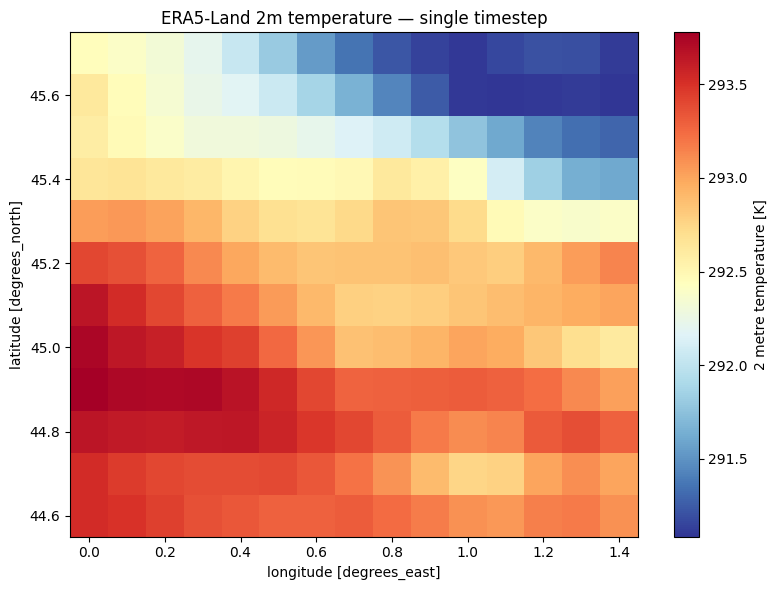

In [13]:
# Quick visual sanity check — temperature map at one timestep
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ds["t2m"].isel(valid_time=12).plot(ax=ax, cmap="RdYlBu_r")
ax.set_title("ERA5-Land 2m temperature — single timestep")
plt.tight_layout()
plt.show()

## 4. Fetch SEAS5 seasonal forecast

**CLI equivalent:**
```bash
irrigator fetch seas5 --year 2026 --month 6
```

In [14]:
from irrigator.ingestion.cds_client import fetch_seas5, open_seas5

path = fetch_seas5(cfg, year=2026, month=6)
print(f"Downloaded: {path}")

seas5 = open_seas5(cfg, year=2026, month=6)
print(seas5)

09:42:59 [irrigator.ingestion.cds_client] INFO: Requesting SEAS5 2026-06 from CDS...
2026-05-28 09:43:00,154 INFO Request ID is b17ac573-aa95-444b-9c61-cbf2be3ef821
09:43:00 [ecmwf.datastores.legacy_client] INFO: Request ID is b17ac573-aa95-444b-9c61-cbf2be3ef821
2026-05-28 09:43:01,145 INFO status has been updated to accepted
09:43:01 [ecmwf.datastores.legacy_client] INFO: status has been updated to accepted


KeyboardInterrupt: 

## 5. Fetch AROME + ARPEGE forecasts

**CLI equivalent:**
```bash
irrigator fetch forecasts
```

Requires `METEOFRANCE_API_KEY` environment variable.

In [ ]:
import os
os.environ["METEOFRANCE_API_KEY"] = "your-key-here"  # uncomment and set

from irrigator.ingestion.meteofrance_client import fetch_latest_forecasts

results = fetch_latest_forecasts(cfg)
for model, path in results.items():
    print(f"{model.upper()}: {path}")

## 6. Fetch COMEPHORE precipitation

**CLI equivalent:**
```bash
irrigator fetch comephore --start 2022-07-01 --end 2022-07-31
```

In [ ]:
from irrigator.ingestion.meteofrance_client import fetch_comephore_daily, fetch_comephore_range

# Test with a single day
path = fetch_comephore_daily(cfg, date(2022, 7, 15))
print(f"Downloaded: {path}")

In [ ]:
# Full month (run after single day works)
# paths = fetch_comephore_range(cfg, date(2022, 7, 1), date(2022, 7, 31))
# print(f"Downloaded {len(paths)} daily files")

## 7. Build static layers (soil + terrain)

**CLI equivalent:**
```bash
irrigator build-static
```

Requires:
- EU-SoilHydroGrids TIFFs in `data/static/dordogne/eu_soilhydrogrids/`
- DEM tiles in `data/static/dordogne/dem/`

### 7a. Soil hydraulic properties

In [3]:
from irrigator.ingestion.esdac_loader import load_soil_hydro, save_soil_hydro

soil = load_soil_hydro(cfg, grid)

print(f"Depths: {soil.depths_cm}")
print(f"FC shape: {soil.fc.shape}")
print(f"Median total AWC: {float(soil.total_awc_mm.median()):.0f} mm")
print(f"AWC range: [{float(soil.total_awc_mm.min()):.0f}, {float(soil.total_awc_mm.max()):.0f}] mm")

# Save for later blocks
save_soil_hydro(soil, cfg.processed_dir / "static")

12:39:39 [irrigator.ingestion.esdac_loader] INFO: Using tile index: /home/mbaldacchino/code/IrriGator/data/static/eu_soilhydrogrids/grid_cells_250m_wgs84.gpkg
12:39:39 [irrigator.ingestion.esdac_loader] INFO: Tile index: 7 tiles intersect region, 7 exist on disk
12:39:39 [irrigator.ingestion.esdac_loader] INFO: Loading EU-SoilHydroGrids: 3 variables × 6 layers from 7 tiles
12:39:40 [irrigator.ingestion.esdac_loader] INFO: Loaded FC: 6 layers
12:39:41 [irrigator.ingestion.esdac_loader] INFO: Loaded WP: 6 layers
12:39:41 [irrigator.ingestion.esdac_loader] INFO: Loaded KS: 6 layers
12:39:42 [irrigator.ingestion.esdac_loader] INFO: Soil data loaded: grid (513, 471), 7 tiles, median AWC = 26551 mm, range [0, 35080] mm


Depths: [(0, 5), (5, 15), (15, 30), (30, 60), (60, 100), (100, 200)]
FC shape: (6, 513, 471)
Median total AWC: 26551 mm
AWC range: [0, 35080] mm


12:39:43 [irrigator.ingestion.esdac_loader] INFO: Saved soil data: /home/mbaldacchino/code/IrriGator/data/processed/dordogne/static/soil_hydro.nc


PosixPath('/home/mbaldacchino/code/IrriGator/data/processed/dordogne/static/soil_hydro.nc')

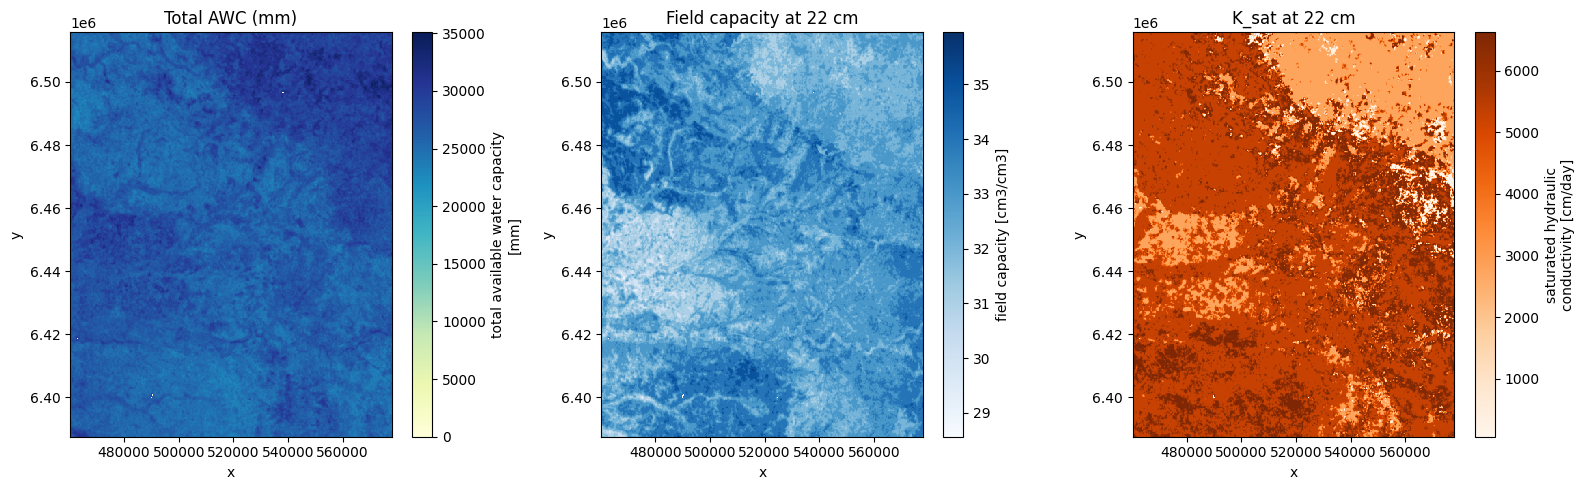

In [4]:
# Visual check — total AWC map
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

soil.total_awc_mm.plot(ax=axes[0], cmap="YlGnBu")
axes[0].set_title("Total AWC (mm)")

soil.fc.sel(depth=soil.fc.depth[2]).plot(ax=axes[1], cmap="Blues")
axes[1].set_title(f"Field capacity at {float(soil.fc.depth[2]):.0f} cm")

soil.ks.sel(depth=soil.ks.depth[2]).plot(ax=axes[2], cmap="Oranges")
axes[2].set_title(f"K_sat at {float(soil.ks.depth[2]):.0f} cm")

plt.tight_layout()
plt.show()

### 7b. Terrain (DEM, slope, aspect)

In [4]:
from irrigator.ingestion.ign_loader import load_terrain, save_terrain

terrain = load_terrain(cfg, grid)

print(f"Elevation range: [{float(terrain.elevation.min()):.0f}, {float(terrain.elevation.max()):.0f}] m")
print(f"Slope range:     [{float(terrain.slope.min()):.1f}, {float(terrain.slope.max()):.1f}]°")

# Save for later blocks
save_terrain(terrain, cfg.processed_dir / "static")

15:18:40 [irrigator.ingestion.ign_loader] INFO: Mosaicking 432 DEM tiles from /home/mbaldacchino/code/IrriGator/data/static/dem
15:19:23 [irrigator.ingestion.ign_loader] INFO: DEM mosaic: 24000 × 27000 at 5.0 m, CRS EPSG:5698
15:19:52 [irrigator.ingestion.ign_loader] INFO: Slope range: [0.0°, 90.0°], median 2.7°
15:19:52 [irrigator.ingestion.ign_loader] INFO: Aggregating terrain to 250 m grid...


Elevation range: [-99999, 540] m
Slope range:     [0.0, 32.9]°


15:20:06 [irrigator.ingestion.ign_loader] INFO: Saved terrain data: /home/mbaldacchino/code/IrriGator/data/processed/dordogne/static/terrain.nc


PosixPath('/home/mbaldacchino/code/IrriGator/data/processed/dordogne/static/terrain.nc')

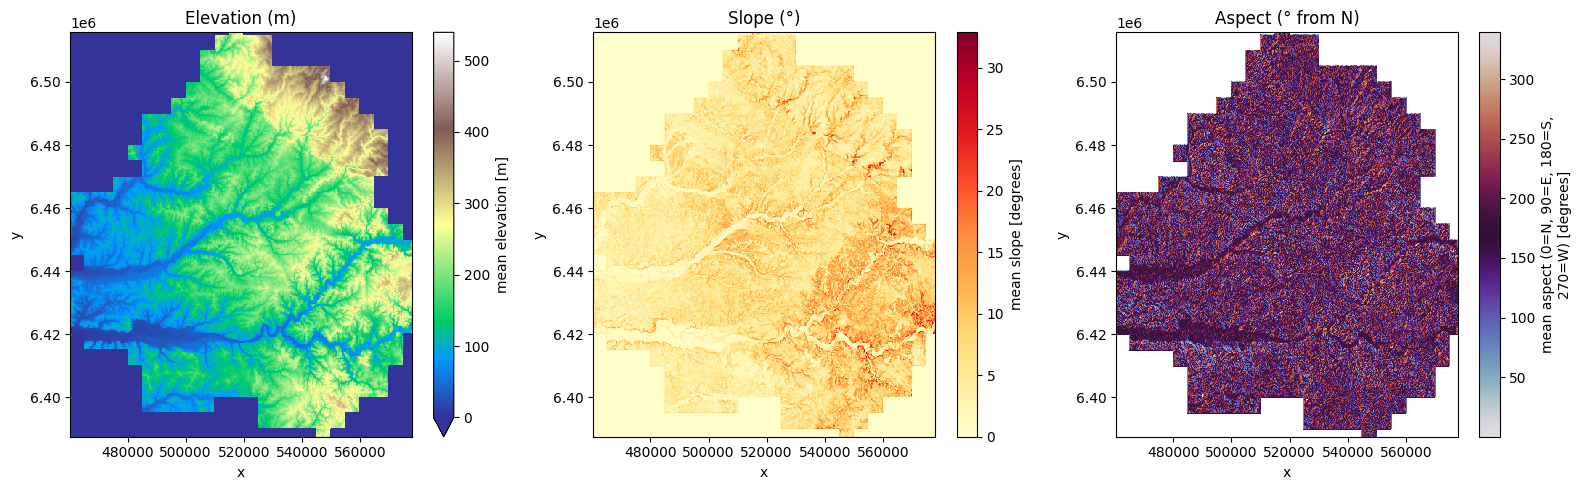

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

terrain.elevation.plot(ax=axes[0], cmap="terrain", vmin=0)
axes[0].set_title("Elevation (m)")

terrain.slope.plot(ax=axes[1], cmap="YlOrRd")
axes[1].set_title("Slope (°)")

terrain.aspect.plot(ax=axes[2], cmap="twilight")
axes[2].set_title("Aspect (° from N)")

plt.tight_layout()
plt.show()

## 8. Fetch Sentinel-2 NDVI

**CLI equivalent:**
```bash
irrigator fetch ndvi --date 2022-07-15
```

Requires THEIA credentials.

In [ ]:
# os.environ["THEIA_TOKEN"] = "your-token"  # uncomment and set

from irrigator.ingestion.theia_client import search_scenes, fetch_and_process_ndvi

In [ ]:
# Step 1: check what scenes are available
scenes = search_scenes(cfg, date(2022, 7, 1), date(2022, 7, 31))
for s in scenes[:5]:
    print(f"{s['id']}  {s['datetime']}  cloud={s['cloud_cover']}%")

In [ ]:
# Step 2: download + compute NDVI for a target date
ndvi = fetch_and_process_ndvi(cfg, grid, date(2022, 7, 15), search_window_days=10)

if ndvi is not None:
    print(f"NDVI shape: {ndvi.shape}")
    print(f"Median: {float(ndvi.median()):.2f}")

    fig, ax = plt.subplots(figsize=(8, 6))
    ndvi.isel(time=0).plot(ax=ax, cmap="RdYlGn", vmin=-0.1, vmax=0.9)
    ax.set_title("Sentinel-2 NDVI")
    plt.tight_layout()
    plt.show()
else:
    print("No scene found — check THEIA credentials and date range")

## 9. Load a parcel config

Not a CLI command — just shows how to read a parcel config
and extract the grid cell values for that parcel.

In [ ]:
from irrigator.config import load_parcel_config

parcel = load_parcel_config("configs/parcels/example.yaml")

print(f"Parcel:   {parcel.name} ({parcel.id})")
print(f"Farmer:   {parcel.farmer}")
print(f"Location: {parcel.lat}, {parcel.lon}")
print(f"Area:     {parcel.area_ha} ha")
print(f"Crop:     {parcel.crop.get('type')}")
print(f"Planting: {parcel.crop.get('planting_date')}")
print(f"Variety:  {parcel.crop.get('variety')}")
print(f"Soil source: {parcel.soil.get('source', 'eu_soilhydrogrids')}")

In [ ]:
# Extract soil values at the parcel location
# Convert parcel lat/lon (WGS84) to Lambert-93 first
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:4326", "EPSG:2154", always_xy=True)
parcel_x, parcel_y = transformer.transform(parcel.lon, parcel.lat)
print(f"Parcel in L93: x={parcel_x:.0f}, y={parcel_y:.0f}")

# Find nearest grid cell
parcel_awc = float(soil.total_awc_mm.sel(x=parcel_x, y=parcel_y, method="nearest"))
print(f"AWC at parcel: {parcel_awc:.0f} mm")

parcel_elev = float(terrain.elevation.sel(x=parcel_x, y=parcel_y, method="nearest"))
print(f"Elevation at parcel: {parcel_elev:.0f} m")

---

## Summary: what should be on disk after running this notebook

```
data/
  raw/
    dordogne/
      era5_land/
        era5land_2022_07.nc
      seas5/
        seas5_2026_06.nc
      arome/
        arome_2026-05-26_00z.grib2
      arpege/
        arpege_2026-05-26_00z.grib2
      comephore/
        comephore_2022-07-15.nc
      sentinel2/
        <scene_id>_B4.tif
        <scene_id>_B8.tif
  processed/
    dordogne/
      static/
        soil_hydro.nc
        terrain.nc
  static/
    dordogne/
      eu_soilhydrogrids/   ← you place TIFFs here manually
      dem/                 ← you place DEM tiles here manually
    admin_express/         ← shared across regions
      DEPARTEMENT.shp
```

Block 0 is done. Next: Block 2 (atmospheric forcing / downscaling).